In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import time, json, os, re
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB
import json
import geopandas as gpd
from funciones_mapas_graficos import graficar_desde_asignaciones_csv, graficar_eeuu_desde_asignaciones_csv

Total polígonos: 796
Asignados: 796
No asignados: 0


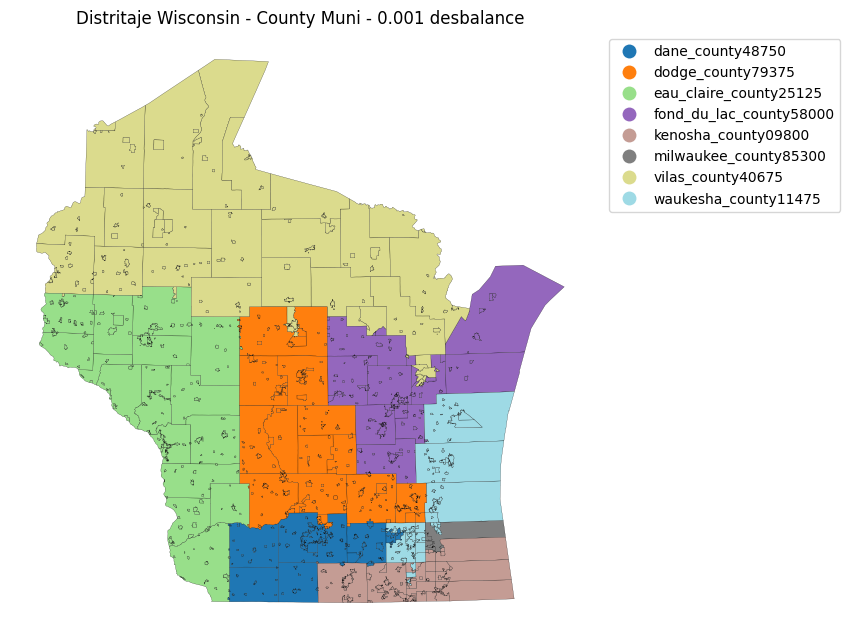

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,dodge_county79375
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,dodge_county79375
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,dodge_county79375
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,dodge_county79375
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,dodge_county79375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,dodge_county79375
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,dodge_county79375
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,dodge_county79375
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,dodge_county79375


In [6]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_055/t_055_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t055.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 796
Asignados: 796
No asignados: 0


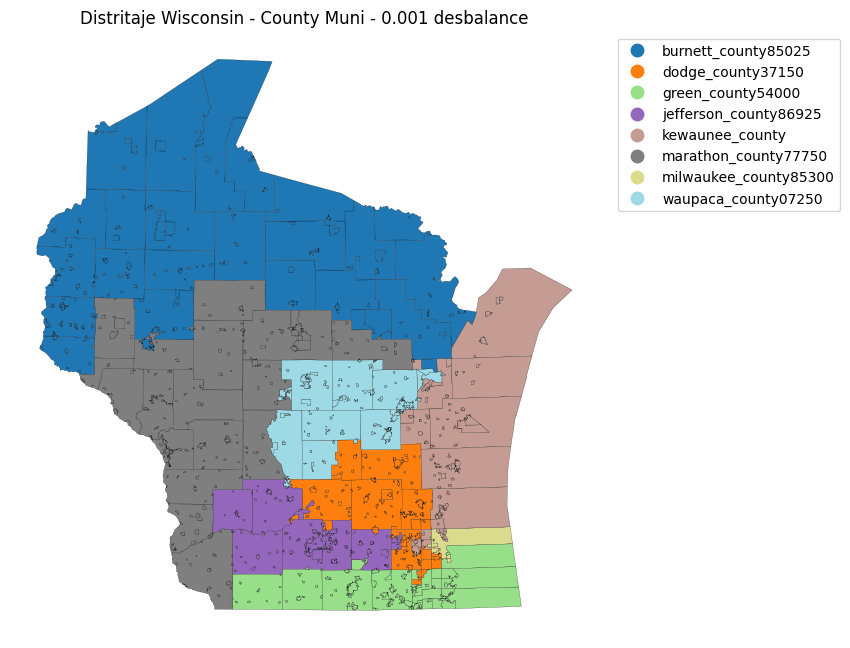

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,waupaca_county07250
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,waupaca_county07250
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,waupaca_county07250
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,waupaca_county07250
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,waupaca_county07250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,marathon_county77750
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,waupaca_county07250
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,marathon_county77750
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,marathon_county77750


In [5]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_077/t_077_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t077.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 796
Asignados: 796
No asignados: 0


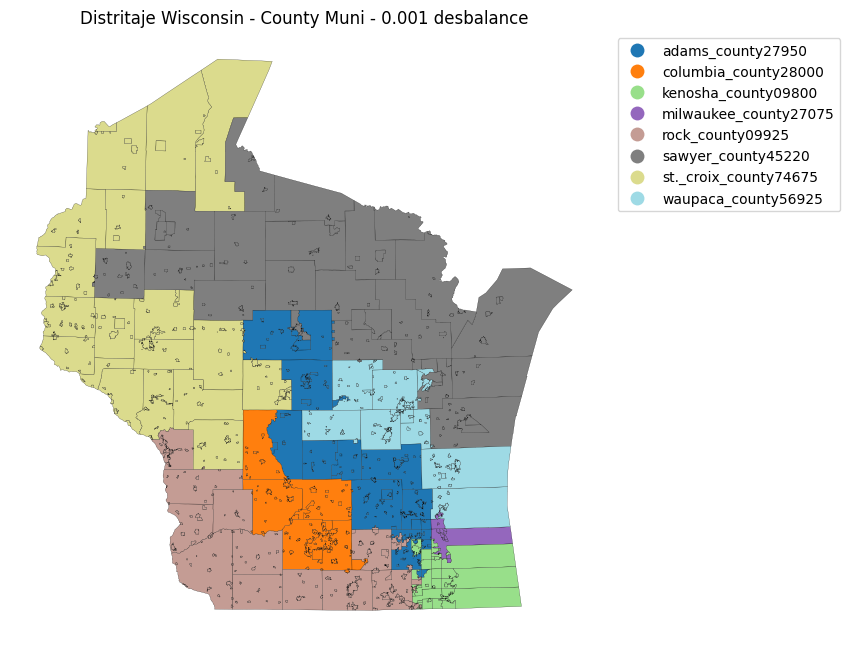

,county_muni_id,county_muni,state,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00275,Adams County00275,WI,Adams County,00275,1761.0,75.0,1591.0,14.0,6.0,...,457.8,321.9,357.4,320.6,7.626484e+06,5361.0,0,"POLYGON ((616255.173 12442.083, 615057.896 124...",adams_county00275,adams_county27950
1,Adams County,Adams County,WI,Adams County,,15538.0,622.0,13671.0,540.0,150.0,...,5534.7,3132.0,4147.2,2925.0,1.605153e+09,87642140.0,1,"POLYGON ((612791.172 -10728.98, 612615.458 -83...",adams_county,adams_county27950
2,Adams County27950,Adams County27950,WI,Adams County,27950,648.0,23.0,585.0,11.0,1.0,...,170.4,111.2,136.6,115.5,2.331113e+06,114293.0,2,"POLYGON ((615424.615 14850.243, 614618.606 148...",adams_county27950,adams_county27950
3,Adams County19600,Adams County19600,WI,Adams County,19600,940.0,14.0,888.0,1.0,3.0,...,352.2,248.2,271.5,231.3,2.961059e+07,17433201.0,3,"POLYGON ((602993.223 14773.007, 604207.092 147...",adams_county19600,adams_county27950
4,Adams County41160,Adams County41160,WI,Adams County,41160,1104.0,15.0,1067.0,1.0,3.0,...,514.0,313.0,418.3,293.0,1.868517e+07,2019933.0,4,"POLYGON ((615816.492 41008.632, 616402.878 411...",adams_county41160,adams_county27950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,Wood County63100,Wood County63100,WI,Wood County,63100,813.0,15.0,778.0,0.0,6.0,...,305.0,137.0,244.4,132.4,5.154736e+06,26373.0,791,"POLYGON ((590476.373 65676.607, 588907.988 656...",wood_county63100,st._croix_county74675
792,Wood County64175,Wood County64175,WI,Wood County,64175,1762.0,41.0,1585.0,16.0,13.0,...,574.0,442.5,490.4,405.3,1.355627e+07,3228745.0,792,"MULTIPOLYGON (((616701.295 56377.84, 616716.52...",wood_county64175,st._croix_county74675
793,Wood County70000,Wood County70000,WI,Wood County,70000,433.0,20.0,410.0,0.0,2.0,...,164.0,103.0,124.1,104.1,3.118688e+06,0.0,793,"POLYGON ((616698.313 73662.307, 616713.513 732...",wood_county70000,st._croix_county74675
794,Wood County82650,Wood County82650,WI,Wood County,82650,513.0,4.0,484.0,0.0,0.0,...,204.6,95.8,169.6,91.1,2.990849e+06,0.0,794,"POLYGON ((602841.427 72869.078, 603111.314 728...",wood_county82650,st._croix_county74675


In [4]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/wi_sys/t_034/t_034_asignaciones.csv",
    "DataEEUU2/wi_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_wisconsin_county_muni_t034.png",
    titulo="Distritaje Wisconsin - County Muni - 0.001 desbalance",
    col_geo="county_muni"
)

Total polígonos: 67
Asignados: 67
No asignados: 0


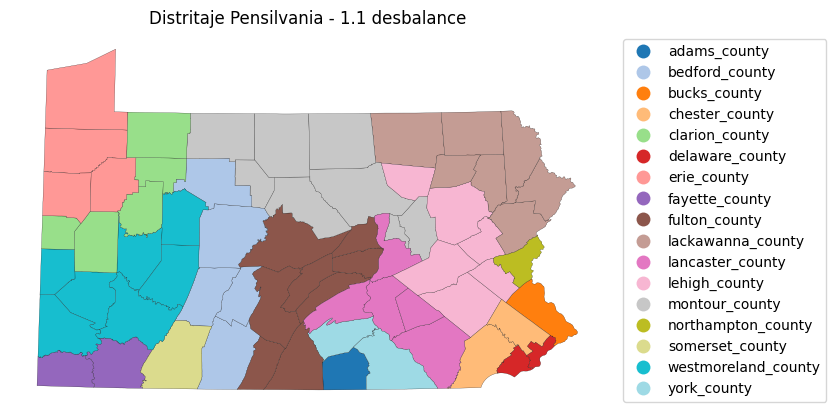

In [6]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu/pa_sys/t_012/t_012_asignaciones.csv",
    "DataEEUU/pa_paper/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_pensilvania_t012.png",
    titulo="Distritaje Pensilvania - 1.1 desbalance",
    col_geo="county"
)

Total polígonos: 1439
Asignados: 1439
No asignados: 0


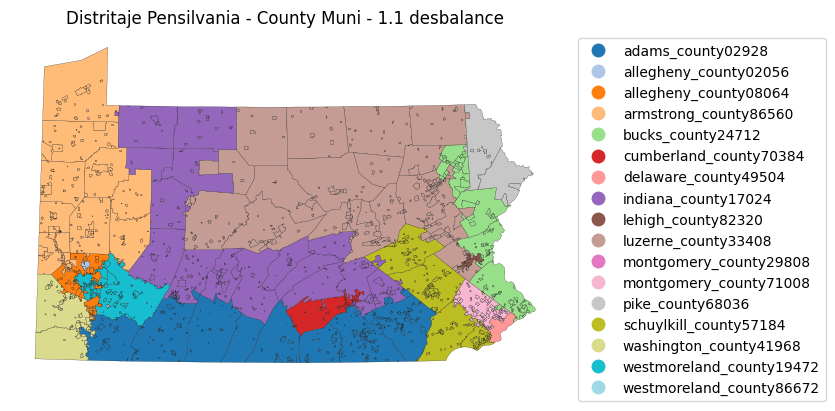

In [2]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/pa_sys/t_012/t_012_asignaciones.csv",
    "DataEEUU2/pa_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_pensilvania_county_muni_t012.png",
    titulo="Distritaje Pensilvania - County Muni - 1.1 desbalance",
    col_geo="county_muni"
)

Total polígonos: 1439
Asignados: 1439
No asignados: 0


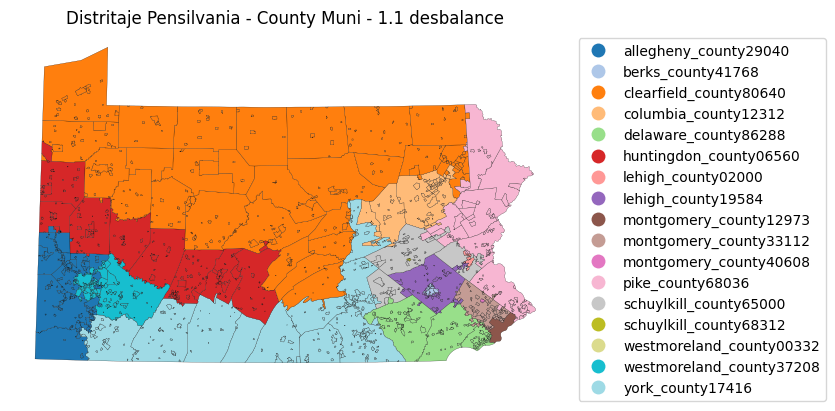

,county_muni_id,county_muni,county,muni,pop,pop_hisp,pop_white,pop_black,pop_aian,pop_asian,...,arv_20,adv_20,nrv,ndv,area_land,area_water,node_idx,geometry,comuna,centro
0,Adams County00116,Adams County00116,Adams County,00116,1022.0,132.0,853.0,7.0,1.0,2.0,...,350.5,139.5,272.6,132.3,1.414125e+06,19834.0,0,"POLYGON ((664395.137 -31011.796, 664509.443 -3...",adams_county00116,york_county17416
1,Adams County02928,Adams County02928,Adams County,02928,867.0,175.0,670.0,9.0,0.0,5.0,...,266.0,171.5,225.8,155.2,2.073962e+06,0.0,1,"POLYGON ((639001.171 -26522.996, 639289.978 -2...",adams_county02928,york_county17416
2,Adams County05536,Adams County05536,Adams County,46376,736.0,265.0,428.0,8.0,1.0,0.0,...,196.5,101.5,152.0,87.9,1.169782e+06,0.0,2,"POLYGON ((642210.844 -20529.128, 642226.305 -1...",adams_county05536,york_county17416
3,Adams County,Adams County,Adams County,,70822.0,4514.0,62642.0,820.0,82.0,554.0,...,27262.0,12063.0,22439.9,10532.1,1.281869e+09,6691218.0,3,"POLYGON ((630716.182 -46852.499, 630574.28 -47...",adams_county,york_county17416
4,Adams County06296,Adams County06296,Adams County,07560,1225.0,231.0,930.0,13.0,3.0,4.0,...,359.0,195.0,300.6,167.4,1.686050e+06,5107.0,4,"POLYGON ((642244.515 -26117.248, 642358.161 -2...",adams_county06296,york_county17416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1434,York County87048,York County87048,York County,87048,44800.0,17076.0,14529.0,10370.0,92.0,384.0,...,3583.5,9195.5,2833.5,8797.6,1.370734e+07,126494.0,1434,"POLYGON ((685579.841 -23314.194, 685411.406 -2...",york_county87048,york_county17416
1435,York County78115,York County78115,York County,78115,3390.0,290.0,2578.0,267.0,9.0,137.0,...,895.5,924.0,793.3,794.8,3.997152e+06,0.0,1435,"POLYGON ((690970.515 -25227.018, 690663.998 -2...",york_county78115,york_county17416
1436,York County73528,York County73528,York County,73528,3669.0,194.0,3097.0,187.0,5.0,80.0,...,1075.0,844.5,938.2,758.1,5.217815e+06,0.0,1436,"POLYGON ((691539.477 -27108.932, 691621.489 -2...",york_county73528,york_county17416
1437,York County87080,York County87080,York County,,686.0,55.0,551.0,25.0,2.0,2.0,...,164.0,93.0,128.1,77.7,7.719730e+05,68747.0,1437,"POLYGON ((688241.472 -5102.936, 688599.432 -53...",york_county87080,delaware_county86288


In [4]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/pa_sys/t_034/t_034_asignaciones.csv",
    "DataEEUU2/pa_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_pensilvania_county_muni_t034.png",
    titulo="Distritaje Pensilvania - County Muni - 1.1 desbalance",
    col_geo="county_muni"
)

In [ ]:
graficar_eeuu_desde_asignaciones_csv(
    "resultados_eeuu_county_muni/pa_sys/t_034/t_034_asignaciones.csv",
    "DataEEUU2/pa_paper_county_muni/nodes.geojson",
    "MAPAS_EEUU_GRAFICOS/mapa_pensilvania_county_muni_t034.png",
    titulo="Distritaje Pensilvania - County Muni - 1.1 desbalance",
    col_geo="county_muni"
)

In [2]:
import geopandas as gpd
import pandas as pd

ruta_geojson = "DataChileMANZANAS/salida_grafo_chile_2024/chile_2024_componente_principal.geojson"

gdf_nodes = gpd.read_file(ruta_geojson)

print(gdf_nodes.columns)
print(gdf_nodes[["ID_DISTRITO", "REGION", "COMUNA", "DISTRITO"]].head())

# Crear nombre igual al usado en comunas/asignaciones
gdf_nodes["comuna"] = "dist_" + gdf_nodes["ID_DISTRITO"].astype(int).astype(str)

print(gdf_nodes[["comuna", "ID_DISTRITO", "COMUNA", "DISTRITO"]].head())

Index(['OBJECTID', 'CUT', 'COD_REGION', 'REGION', 'COD_PROVINCIA', 'PROVINCIA',
       'COMUNA', 'DISTRITO', 'COD_DISTRITO', 'TIPO_DISTRITO', 'ID_DISTRITO',
       'SHAPE_Length', 'SHAPE_Area', 'geometry'],
      dtype='object')
   ID_DISTRITO        REGION COMUNA     DISTRITO
0     920108.0  LA ARAUCANÍA  ANGOL  MAITENREHUE
1     920109.0  LA ARAUCANÍA  ANGOL   SAN RAFAEL
2     920107.0  LA ARAUCANÍA  ANGOL    LOS ALPES
3     920106.0  LA ARAUCANÍA  ANGOL      CHANLEO
4     920110.0  LA ARAUCANÍA  ANGOL      ITRAQUE
        comuna  ID_DISTRITO COMUNA     DISTRITO
0  dist_920108     920108.0  ANGOL  MAITENREHUE
1  dist_920109     920109.0  ANGOL   SAN RAFAEL
2  dist_920107     920107.0  ANGOL    LOS ALPES
3  dist_920106     920106.0  ANGOL      CHANLEO
4  dist_920110     920110.0  ANGOL      ITRAQUE


Total polígonos: 2520
Asignados: 2520
No asignados: 0


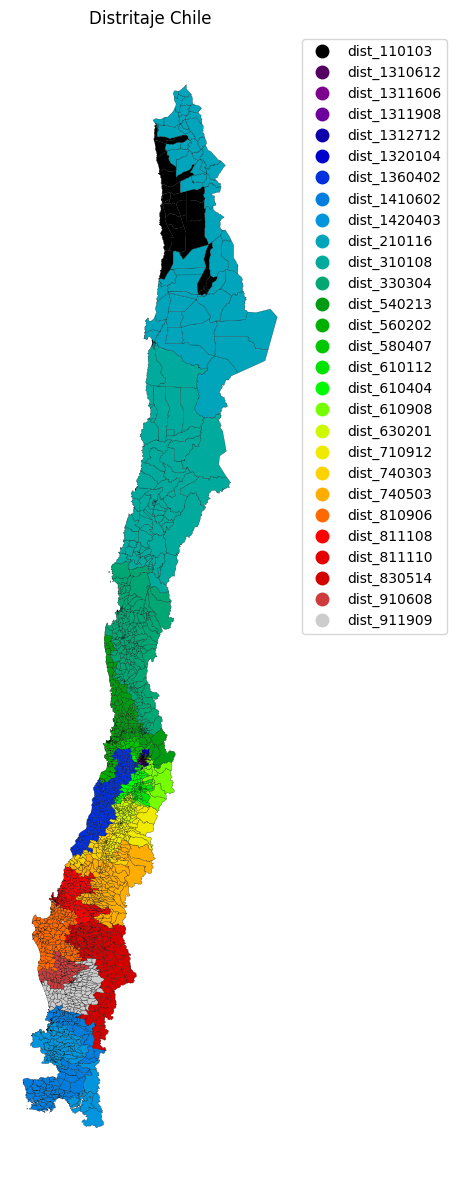

In [ ]:
gdf_mapa = graficar_desde_asignaciones_csv(
    ruta_asignaciones="resultados/CHILE_SL_V2_EPS_0.4/chile_sys_sl_v2_eps_0.4/t_004/t_004_asignaciones.csv",
    ruta_geojson="DataChileMANZANAS/Cartografia_censo2024_Pais_Distrital.parquet",
    output_png="MAPAS_CHILE_GRAFICOS/mapa_chile_sl_v2_t004.png",
    titulo="Distritaje Chile",
    clip_continental=True,
    legend=True 
)

Total polígonos: 2762
Asignados: 2762
No asignados: 0


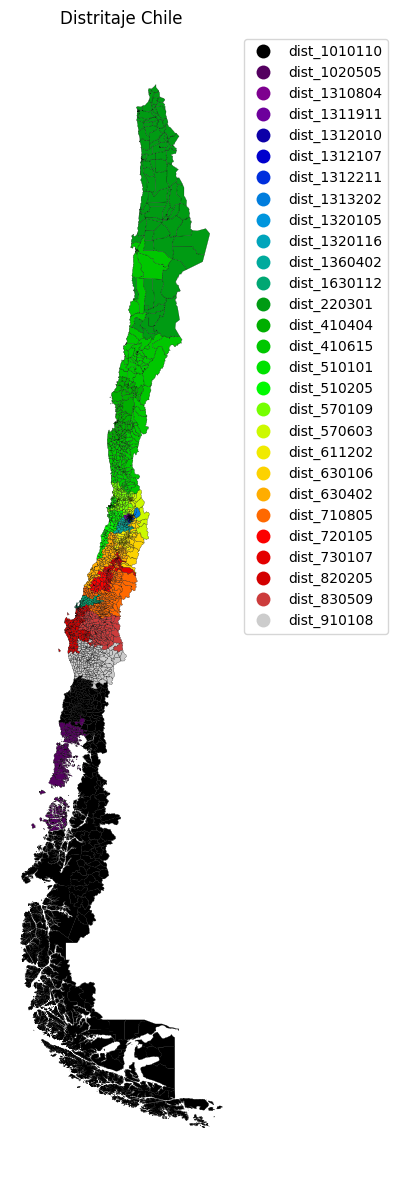

In [5]:
gdf_mapa = graficar_desde_asignaciones_csv(
    ruta_asignaciones="resultados/chile_sys_B_sl_v2_0.4/t_015/t_015_asignaciones.csv",
    ruta_geojson="DataChileMANZANAS/Cartografia_censo2024_Pais_Distrital.parquet",
    output_png="MAPAS_CHILE_GRAFICOS/mapa_chile_B_sl_v2_t015.png",
    titulo="Distritaje Chile",
    clip_continental=True,
    legend=True 
)

Total polígonos: 2762
Asignados: 2762
No asignados: 0


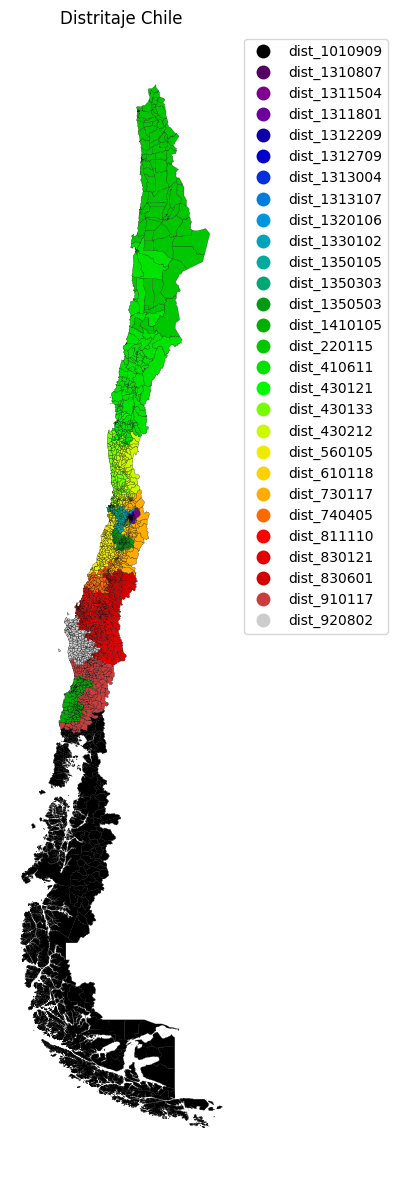

In [3]:
gdf_mapa = graficar_desde_asignaciones_csv(
    ruta_asignaciones="resultados/chile_sys_B_sl_v2_0.4/t_022/t_022_asignaciones.csv",
    ruta_geojson="DataChileMANZANAS/Cartografia_censo2024_Pais_Distrital.parquet",
    output_png="MAPAS_CHILE_GRAFICOS/mapa_chile_B_sl_v2_t022.png",
    titulo="Distritaje Chile",
    clip_continental=True,
    legend=True 
)

Total polígonos: 2762
Asignados: 2762
No asignados: 0


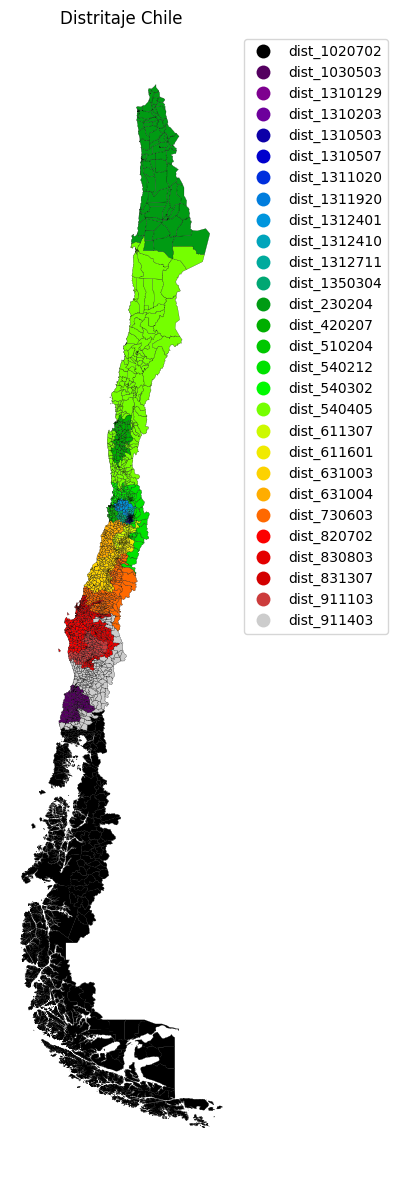

In [2]:
gdf_mapa = graficar_desde_asignaciones_csv(
    ruta_asignaciones="resultados/chile_sys_B_sl_v2_0.4/t_004/t_004_asignaciones.csv",
    ruta_geojson="DataChileMANZANAS/Cartografia_censo2024_Pais_Distrital.parquet",
    output_png="MAPAS_CHILE_GRAFICOS/mapa_chile_B_sl_v2_t004.png",
    titulo="Distritaje Chile",
    clip_continental=True,
    legend=True 
)

In [3]:
import pandas as pd

K = 28

ruta = r"DataChileMANZANAS/data_chile_2024_procesada/caso_A_principal/comunas_chile_2024_caso_A_principal.xlsx"

df = pd.read_excel(ruta)

print(df.columns.tolist())

# Reemplaza "poblacion" por el nombre exacto si difiere
col_pob = "poblacion2017"

pob_total = df[col_pob].sum()
phat = pob_total / K

print(f"Número de unidades: {len(df)}")
print(f"Población total: {pob_total:,}")
print(f"phat: {phat:,.2f}")

['comuna', 'region', 'poblacion2017']
Número de unidades: 2520
Población total: 17,697,129
phat: 632,040.32


In [1]:
import pandas as pd

ruta = r"DataChileMANZANAS/data_chile_2024_procesada/caso_A_principal/comunas_chile_2024_caso_A_principal.xlsx"

df = pd.read_excel(ruta)

# Resumen por región
resumen = (
    df.groupby("region")
      .agg(
          unidades=("comuna", "count"),
          poblacion=("poblacion2017", "sum")
      )
      .sort_index()
)

print(resumen)
print("\nNúmero de regiones:", resumen.shape[0])
print("\nRegiones presentes:")
print(resumen.index.tolist())

                                      unidades  poblacion
region                                                   
antofagasta                                 64     618389
arica_y_parinacota                          37     237430
atacama                                     75     294897
biobio                                     276    1602659
coquimbo                                   208     817236
la_araucania                               298    1003546
libertador_general_bernardo_ohiggins       217     981737
los_lagos                                  106     630637
los_rios                                    94     375343
maule                                      249    1114486
metropolitana_de_santiago                  451    7291744
nuble                                      146     508206
tarapaca                                    39     358910
valparaiso                                 260    1861909

Número de regiones: 14

Regiones presentes:
['antofagasta', 'arica_y_pa

In [8]:
import pandas as pd
import json
import re
import math

eps = 0.63
K = 28

ruta_comunas = r"DataChileMANZANAS/data_chile_2024_procesada/caso_A_principal/comunas_chile_2024_caso_A_principal.xlsx"
ruta_valores = r"datos_modelo/valores_chile_censal_eps_0.63000.json"

df = pd.read_excel(ruta_comunas)
df["comuna"] = df["comuna"].astype(str)

with open(ruta_valores, "r", encoding="utf-8") as f:
    valores = json.load(f)

# Detecta automáticamente variables de centro: todo lo que NO sea asignaciones_ij
vars_centro = {
    k: v for k, v in valores.items()
    if not k.startswith("asignaciones_ij")
}

print("Variables de centro detectadas:", len(vars_centro))
print("Primeras 20:")
for k, v in list(vars_centro.items())[:20]:
    print(k, v)

# Extraer centros con valor 1
centros_fijos = []

for nombre, val in vars_centro.items():
    if abs(val - 1) <= 1e-6:
        m = re.search(r"\[(.*?)\]", nombre)
        if m:
            centros_fijos.append(m.group(1))
        else:
            centros_fijos.append(nombre)

centros_fijos = sorted(set(centros_fijos))

print("\nCentros fijos y=1:", len(centros_fijos))
print(centros_fijos)

df_fijos = df[df["comuna"].isin(centros_fijos)].copy()

print("\nCentros fijos encontrados en Excel:", len(df_fijos))
print(df_fijos[["comuna", "region", "poblacion2017"]])

phat = df["poblacion2017"].sum() / K
lb = phat * (1 - eps)

res = df.groupby("region")["poblacion2017"].sum().to_frame("poblacion")

res["centros_fijos"] = (
    df_fijos.groupby("region")["comuna"]
    .count()
)

res["centros_fijos"] = res["centros_fijos"].fillna(0).astype(int)
res["max_centros"] = (res["poblacion"] // lb).astype(int)
res["cupos_restantes"] = res["max_centros"] - res["centros_fijos"]

print("\nphat:", phat)
print("lb:", lb)

print("\nResumen:")
print(res.sort_values("cupos_restantes"))

print("\nRegiones donde NO puede caer otro centro:")
print(res[res["cupos_restantes"] <= 0])

Variables de centro detectadas: 2520
Primeras 20:
centros_j[dist_210405] 0.0
centros_j[dist_210407] 0.0
centros_j[dist_210408] 0.0
centros_j[dist_210402] 0.0
centros_j[dist_210401] 0.0
centros_j[dist_210409] 0.0
centros_j[dist_210406] 0.0
centros_j[dist_210404] 0.0
centros_j[dist_210403] 0.0
centros_j[dist_210111] 0.0
centros_j[dist_210114] 0.0
centros_j[dist_210102] 0.0
centros_j[dist_210116] 0.0
centros_j[dist_210115] 0.0
centros_j[dist_210117] 0.0
centros_j[dist_210118] 0.0
centros_j[dist_210103] 0.0
centros_j[dist_210106] 0.0
centros_j[dist_210107] 0.0
centros_j[dist_210108] 0.0

Centros fijos y=1: 24
['dist_1010214', 'dist_1310704', 'dist_1311020', 'dist_1350114', 'dist_1360501', 'dist_140102', 'dist_1420405', 'dist_1520108', 'dist_1610805', 'dist_1630401', 'dist_220109', 'dist_220201', 'dist_330401', 'dist_410217', 'dist_410408', 'dist_550202', 'dist_560104', 'dist_560602', 'dist_611001', 'dist_730409', 'dist_730802', 'dist_740705', 'dist_810303', 'dist_912004']

Centros fijos en

In [9]:
import pandas as pd
import json
import re

eps = 0.63
K = 28

ruta_comunas = r"DataChileMANZANAS/data_chile_2024_procesada/caso_A_principal/comunas_chile_2024_caso_A_principal.xlsx"
ruta_valores = r"datos_modelo/valores_chile_censal_eps_0.63000.json"

df = pd.read_excel(ruta_comunas)
df["comuna"] = df["comuna"].astype(str)

with open(ruta_valores, "r", encoding="utf-8") as f:
    valores = json.load(f)

# Extraer variables centros_j[...]
rows = []
pat = re.compile(r"centros_j\[(.*?)\]")

for nombre, val in valores.items():
    m = pat.match(nombre)
    if m:
        rows.append({
            "comuna": m.group(1),
            "y": val
        })

df_y = pd.DataFrame(rows)

# Agregar región y población
df_y = df_y.merge(
    df[["comuna", "region", "poblacion2017"]],
    on="comuna",
    how="left"
)

# Separar fijos y fraccionarios
fijos = df_y[df_y["y"] >= 1 - 1e-6].copy()
frac = df_y[(df_y["y"] > 1e-6) & (df_y["y"] < 1 - 1e-6)].copy()

print("Centros fijos y=1:", len(fijos))
print("Centros fraccionarios 0<y<1:", len(frac))
print("Suma y fraccionarios:", frac["y"].sum())
print("Suma total y:", df_y["y"].sum())

print("\nFraccionarios por región:")
res_frac = (
    frac.groupby("region")
        .agg(
            n_frac=("comuna", "count"),
            suma_y=("y", "sum"),
            max_y=("y", "max")
        )
        .sort_values("suma_y", ascending=False)
)

print(res_frac)

print("\nDetalle de centros fraccionarios:")
print(
    frac.sort_values(["region", "y"], ascending=[True, False])
        [["comuna", "region", "poblacion2017", "y"]]
        .to_string(index=False)
)

Centros fijos y=1: 24
Centros fraccionarios 0<y<1: 14
Suma y fraccionarios: 4.0000000000000036
Suma total y: 28.000000000000004

Fraccionarios por región:
                           n_frac    suma_y     max_y
region                                               
metropolitana_de_santiago      11  3.077812  0.925356
biobio                          2  0.827183  0.413592
antofagasta                     1  0.095005  0.095005

Detalle de centros fraccionarios:
      comuna                    region  poblacion2017        y
 dist_210303               antofagasta            884 0.095005
 dist_831305                    biobio            475 0.413592
 dist_810702                    biobio          12609 0.413592
dist_1312802 metropolitana_de_santiago          17042 0.925356
dist_1311921 metropolitana_de_santiago          15340 0.424911
dist_1340206 metropolitana_de_santiago           5478 0.407626
dist_1311207 metropolitana_de_santiago          20828 0.336129
dist_1312701 metropolitana_de_santia

In [10]:
phat = df["poblacion2017"].sum() / K
lb = phat * (1 - eps)

pob_region = df.groupby("region")["poblacion2017"].sum()
centros_fijos_region = fijos.groupby("region")["comuna"].count()

res = pd.DataFrame({
    "poblacion": pob_region,
    "centros_fijos": centros_fijos_region
}).fillna(0)

res["centros_fijos"] = res["centros_fijos"].astype(int)
res["max_centros"] = (res["poblacion"] // lb).astype(int)
res["cupos_restantes"] = res["max_centros"] - res["centros_fijos"]

res_frac_region = frac.groupby("region")["y"].sum().rename("masa_frac_region")

res = res.join(res_frac_region).fillna({"masa_frac_region": 0})
res["riesgo_infactible"] = (res["cupos_restantes"] <= 0) & (res["masa_frac_region"] > 1e-9)

print(
    res.sort_values(["riesgo_infactible", "masa_frac_region"], ascending=False)
)

print("\nRegiones con riesgo directo:")
print(res[res["riesgo_infactible"]])

                                      poblacion  centros_fijos  max_centros  \
region                                                                        
antofagasta                              618389              2            2   
metropolitana_de_santiago               7291744              4           31   
biobio                                  1602659              1            6   
arica_y_parinacota                       237430              1            1   
atacama                                  294897              1            1   
coquimbo                                 817236              2            3   
la_araucania                            1003546              1            4   
libertador_general_bernardo_ohiggins     981737              1            4   
los_lagos                                630637              1            2   
los_rios                                 375343              1            1   
maule                                   1114486     

---

In [8]:

def limpiar_nombre_chile(x):
    return (
        str(x).strip().lower()
        .replace("á", "a").replace("é", "e").replace("í", "i")
        .replace("ó", "o").replace("ú", "u").replace("ü", "u")
        .replace("ñ", "n").replace("'", "")
        .replace(" ", "_")
    )
import pyarrow.parquet as pq
from shapely import wkb
import geopandas as gpd

def leer_distritos_chile_2024(path_parquet):
    table = pq.read_table(path_parquet)
    df = table.to_pandas()

    df["geometry"] = df["SHAPE"].apply(
        lambda x: wkb.loads(bytes(x)) if x is not None else None
    )

    gdf = gpd.GeoDataFrame(
        df,
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdf["comuna"] = "dist_" + gdf["ID_DISTRITO"].astype(int).astype(str)

    return gdf

In [35]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import random

def normalizar_id_distrito(x):
    """
    Convierte distintos formatos de identificador al formato:
    dist_123
    """
    x = limpiar_nombre_chile(x)

    if x.startswith("dist_"):
        return x

    # Casos como 123 o 123.0
    try:
        return f"dist_{int(float(x))}"
    except (ValueError, TypeError):
        return x


def graficar_camino_local_chile(
    dict_adyacencia,
    unidad_inicial=None,
    longitud_camino=3,
    ruta_parquet=(
        "DataChileMANZANAS/"
        "Cartografia_censo2024_Pais_Distrital.parquet"
    ),
    ruta_comunas=(
        "DataChileMANZANAS/"
        "data_chile_2024_procesada/"
        "caso_B_conectado/"
        "comunas_chile_2024_caso_B_conectado.xlsx"
    ),
    output_png="FIGURAS_TESIS/ejemplo_camino_minimo.png",
    incluir_vecinos=True
):
    """
    Grafica un camino mínimo del grafo de distritos de Chile.

    Parámetros
    ----------
    dict_adyacencia : dict
        Diccionario ya cargado. No se debe pasar la ruta del .txt.

    unidad_inicial : str, int o None
        Nodo desde el cual comenzar.
        Puede entregarse como 123 o como 'dist_123'.
        Si es None, se selecciona automáticamente un nodo válido.

    longitud_camino : int
        Número exacto de aristas del camino mínimo buscado.

    incluir_vecinos : bool
        Si es True, incluye los vecinos inmediatos del camino para
        mostrar el contexto local del grafo.
    """

    # ---------------------------------------------------------
    # 1. Cargar cartografía con la misma función que ya funciona
    # ---------------------------------------------------------

    gdf = leer_distritos_chile_2024(ruta_parquet)

    print(gdf.columns.tolist())

    comunas_B = pd.read_excel(ruta_comunas)
    comunas_B["comuna"] = comunas_B["comuna"].apply(
        normalizar_id_distrito
    )

    gdf["comuna"] = gdf["comuna"].apply(normalizar_id_distrito)

    gdf = gdf[
        gdf["comuna"].isin(comunas_B["comuna"])
    ].copy()

    print("Polígonos del caso B:", len(gdf))

    # ---------------------------------------------------------
    # 2. Construir grafo directamente desde el diccionario
    # ---------------------------------------------------------

    G = nx.Graph()

    for nodo, vecinos in dict_adyacencia.items():

        nodo_normalizado = normalizar_id_distrito(nodo)

        # Permite que los vecinos sean listas, sets, tuplas, etc.
        for vecino in vecinos:
            vecino_normalizado = normalizar_id_distrito(vecino)

            G.add_edge(
                nodo_normalizado,
                vecino_normalizado
            )

    nodos_cartografia = set(gdf["comuna"])
    nodos_validos = set(G.nodes).intersection(nodos_cartografia)

    print("Nodos del grafo:", G.number_of_nodes())
    print("Aristas del grafo:", G.number_of_edges())
    print("Nodos presentes en la cartografía:", len(nodos_validos))

    if not nodos_validos:
        raise ValueError(
            "No existe coincidencia entre los identificadores del "
            "diccionario y la columna 'comuna' de la cartografía."
        )

    # ---------------------------------------------------------
    # 3. Elegir origen y destino
    # ---------------------------------------------------------

    def buscar_destino(origen):
        distancias = nx.single_source_shortest_path_length(
            G,
            origen,
            cutoff=longitud_camino
        )

        candidatos = [
            nodo
            for nodo, distancia in distancias.items()
            if distancia == longitud_camino
            and nodo in nodos_cartografia
        ]

        return candidatos[0] if candidatos else None

    if unidad_inicial is not None:

        origen = normalizar_id_distrito(unidad_inicial)

        if origen not in G:
            raise ValueError(
                f"La unidad inicial '{origen}' no aparece en el "
                "diccionario de adyacencia."
            )

        if origen not in nodos_cartografia:
            raise ValueError(
                f"La unidad inicial '{origen}' no aparece en la "
                "cartografía del caso B."
            )

        destino = buscar_destino(origen)

        if destino is None:
            raise ValueError(
                f"No se encontró un nodo a distancia exacta "
                f"{longitud_camino} desde {origen}."
            )

    else:
        origen = None
        destino = None

        # Selección automática de un par válido
        candidatos_origen = list(nodos_validos)
        random.shuffle(candidatos_origen)

        for candidato_origen in candidatos_origen:

            candidato_destino = buscar_destino(candidato_origen)

            if candidato_destino is not None:
                origen = candidato_origen
                destino = candidato_destino
                break

        if origen is None:
            raise ValueError(
                f"No se encontró ningún par de nodos a distancia "
                f"exacta {longitud_camino}."
            )

    # ---------------------------------------------------------
    # 4. Calcular camino mínimo
    # ---------------------------------------------------------

    camino = nx.shortest_path(
        G,
        source=origen,
        target=destino
    )

    intermedios = camino[1:-1]

    print("\nCamino encontrado:\n")

    for k, nodo in enumerate(camino):

        fila = gdf[gdf["comuna"] == nodo].iloc[0]

        if k == 0:
            rol = "i"
        elif k == len(camino) - 1:
            rol = "j"
        else:
            rol = f"v{k}"

        print(
            f"{rol}: {nodo} | "
            f"{fila['COMUNA']} | "
            f"{fila['REGION']}"
        )

    print(f"\nDistancia = {len(camino)-1}")

    # ---------------------------------------------------------
    # 5. Seleccionar subgrafo local
    # ---------------------------------------------------------

    nodos_locales = set(camino)

    if incluir_vecinos:
        for nodo in camino:
            nodos_locales.update(G.neighbors(nodo))

    nodos_locales &= nodos_cartografia

    gdf_local = gdf[
        gdf["comuna"].isin(nodos_locales)
    ].copy()

    if gdf_local.empty:
        raise ValueError(
            "No se encontraron geometrías para los nodos seleccionados."
        )

    gdf_local["tipo"] = "Contexto"

    gdf_local.loc[
        gdf_local["comuna"].isin(intermedios),
        "tipo"
    ] = "Intermedio"

    gdf_local.loc[
        gdf_local["comuna"] == origen,
        "tipo"
    ] = "Origen i"

    gdf_local.loc[
        gdf_local["comuna"] == destino,
        "tipo"
    ] = "Destino j"

    # Proyección para graficar y calcular puntos interiores
    gdf_local = gdf_local.to_crs(epsg=3857)

    # Puede haber más de una geometría por ID_DISTRITO.
    # Se disuelven para obtener una geometría por nodo.
    gdf_nodos = gdf_local.dissolve(
        by="comuna",
        as_index=False,
        aggfunc={"tipo": "first"}
    )

    gdf_nodos["punto"] = (
        gdf_nodos.geometry.representative_point()
    )

    punto_por_nodo = {
        fila["comuna"]: fila["punto"]
        for _, fila in gdf_nodos.iterrows()
    }

    # ---------------------------------------------------------
    # 6. Graficar polígonos
    # ---------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 9))

    colores = {
        "Contexto": "lightgrey",
        "Intermedio": "gold",
        "Origen i": "royalblue",
        "Destino j": "crimson"
    }

    for tipo, color in colores.items():

        parte = gdf_nodos[gdf_nodos["tipo"] == tipo]

        if not parte.empty:
            parte.plot(
                ax=ax,
                color=color,
                edgecolor="black",
                linewidth=0.7,
                label=tipo,
                zorder=1
            )

    # ---------------------------------------------------------
    # 7. Dibujar aristas locales de contexto
    # ---------------------------------------------------------

    subgrafo = G.subgraph(nodos_locales)

    for a, b in subgrafo.edges:

        if a not in punto_por_nodo or b not in punto_por_nodo:
            continue

        pa = punto_por_nodo[a]
        pb = punto_por_nodo[b]

        ax.plot(
            [pa.x, pb.x],
            [pa.y, pb.y],
            color="grey",
            linewidth=0.8,
            alpha=0.55,
            zorder=2
        )

    # ---------------------------------------------------------
    # 8. Resaltar las aristas del camino mínimo
    # ---------------------------------------------------------

    for a, b in zip(camino[:-1], camino[1:]):

        if a not in punto_por_nodo or b not in punto_por_nodo:
            continue

        pa = punto_por_nodo[a]
        pb = punto_por_nodo[b]

        ax.plot(
            [pa.x, pb.x],
            [pa.y, pb.y],
            color="black",
            linewidth=3,
            zorder=4
        )

    # ---------------------------------------------------------
    # 9. Dibujar nodos y etiquetas
    # ---------------------------------------------------------

    for posicion, nodo in enumerate(camino):

        punto = punto_por_nodo[nodo]

        if posicion == 0:
            etiqueta = r"$i$"
        elif posicion == len(camino)-1:
            etiqueta = r"$j$"
        else:
            etiqueta = rf"$v_{{{posicion}}}$"

        ax.scatter(
            punto.x,
            punto.y,
            s=55,
            color="black",
            zorder=5
        )

        ax.annotate(
            etiqueta,
            xy=(punto.x, punto.y),
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=14,
            fontweight="bold",
            zorder=6
        )

    ax.set_title(
        rf"Camino mínimo $P_{{ij}}$: "
        rf"$\operatorname{{dist}}_G(i,j)={len(camino)-1}$",
        fontsize=15
    )

    ax.set_axis_off()
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1)
    )

    plt.tight_layout()

    output_png = Path(output_png)
    output_png.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    plt.savefig(
        output_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("\nCorrespondencia de etiquetas:\n")

    for k, nodo in enumerate(camino):

        fila = gdf[gdf["comuna"] == nodo].iloc[0]

        if k == 0:
            etiqueta = "i"
        elif k == len(camino)-1:
            etiqueta = "j"
        else:
            etiqueta = f"v{k}"

        print(f"{etiqueta:>2}  →  {fila['COMUNA']} ({fila['REGION']})")

    return camino, gdf_nodos

In [16]:
import ast

ruta_adyacencia = (
    r"C:\Tesis\Códigos\DataChileMANZANAS"
    r"\data_chile_2024_procesada"
    r"\caso_B_conectado"
    r"\adyacencia_nodes_chile_2024_caso_B_conectado.txt"
)

with open(ruta_adyacencia, "r", encoding="utf-8") as f:
    dict_adyacencia = ast.literal_eval(f.read())

print(type(dict_adyacencia))
print("Cantidad de nodos:", len(dict_adyacencia))
print("Primer elemento:", next(iter(dict_adyacencia.items())))

<class 'dict'>
Cantidad de nodos: 2762
Primer elemento: ('dist_920108', ['dist_920103', 'dist_920105', 'dist_920106', 'dist_920107', 'dist_920109'])


['OBJECTID', 'CUT', 'COD_REGION', 'REGION', 'COD_PROVINCIA', 'PROVINCIA', 'COMUNA', 'DISTRITO', 'COD_DISTRITO', 'TIPO_DISTRITO', 'ID_DISTRITO', 'SHAPE_Length', 'SHAPE_Area', 'SHAPE', 'SHAPE_bbox', 'geometry', 'comuna']
Polígonos del caso B: 2762
Nodos del grafo: 2762
Aristas del grafo: 6550
Nodos presentes en la cartografía: 2762

Camino encontrado:

i: dist_1350113 | MELIPILLA | METROPOLITANA DE SANTIAGO
v1: dist_1350110 | MELIPILLA | METROPOLITANA DE SANTIAGO
v2: dist_1350116 | MELIPILLA | METROPOLITANA DE SANTIAGO
v3: dist_1350117 | MELIPILLA | METROPOLITANA DE SANTIAGO
v4: dist_1350111 | MELIPILLA | METROPOLITANA DE SANTIAGO
j: dist_1360402 | PADRE HURTADO | METROPOLITANA DE SANTIAGO

Distancia = 5


C:\Users\andre\AppData\Local\Temp\ipykernel_14132\2947189312.py:385: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(
C:\Users\andre\AppData\Local\Temp\ipykernel_14132\2947189312.py:385: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


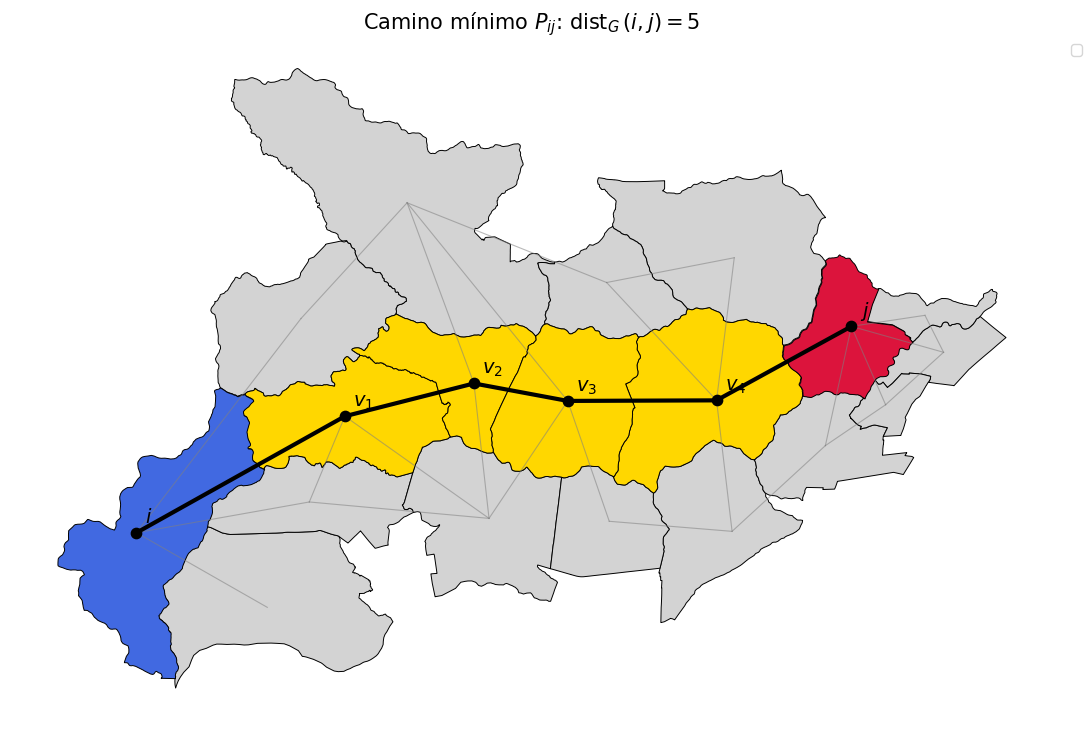


Correspondencia de etiquetas:

 i  →  MELIPILLA (METROPOLITANA DE SANTIAGO)
v1  →  MELIPILLA (METROPOLITANA DE SANTIAGO)
v2  →  MELIPILLA (METROPOLITANA DE SANTIAGO)
v3  →  MELIPILLA (METROPOLITANA DE SANTIAGO)
v4  →  MELIPILLA (METROPOLITANA DE SANTIAGO)
 j  →  PADRE HURTADO (METROPOLITANA DE SANTIAGO)


In [36]:
camino, mapa_local = graficar_camino_local_chile(
    dict_adyacencia=dict_adyacencia,
    unidad_inicial=None,
    longitud_camino=5,
    output_png="FIGURAS_TESIS/ejemplo_camino_minimo.png"
)

In [14]:
import pyarrow.parquet as pq

df = pq.read_table(
    "DataChileMANZANAS/Cartografia_censo2024_Pais_Distrital.parquet",
    columns=["ID_DISTRITO", "REGION", "COMUNA"]
).to_pandas()

ids = [1010101, 1010102, 1010103, 1010115, 1010114, 1010204]

print(df[df["ID_DISTRITO"].isin(ids)])

      ID_DISTRITO     REGION        COMUNA
2574    1010204.0  LOS LAGOS       CALBUCO
2599    1010114.0  LOS LAGOS  PUERTO MONTT
2600    1010115.0  LOS LAGOS  PUERTO MONTT
2602    1010102.0  LOS LAGOS  PUERTO MONTT
2604    1010103.0  LOS LAGOS  PUERTO MONTT
2614    1010101.0  LOS LAGOS  PUERTO MONTT
